xgboost optimised


/Users/parthsanghvi/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [00:08:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       200
           1       0.80      0.56      0.66        50

    accuracy                           0.88       250
   macro avg       0.85      0.76      0.79       250
weighted avg       0.88      0.88      0.88       250



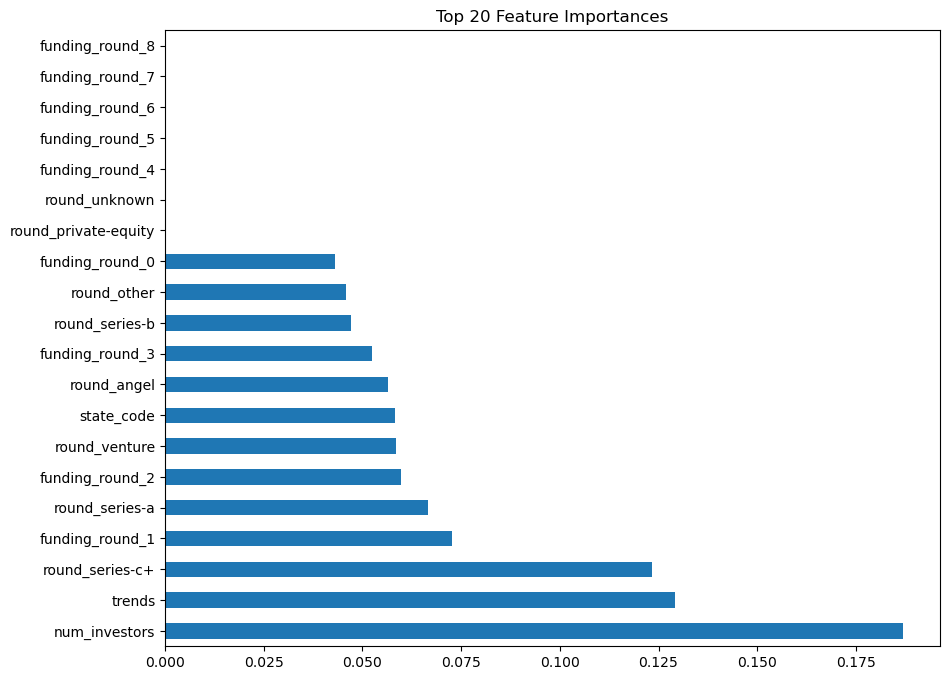

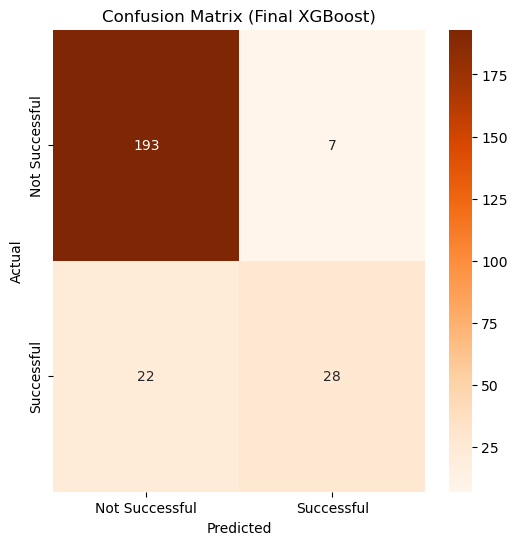

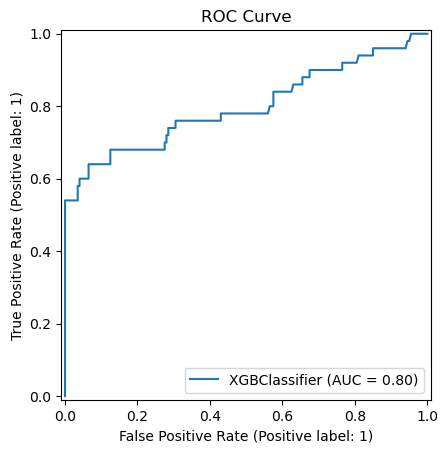

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Load and clean data
df = pd.read_csv("/Users/parthsanghvi/Downloads/testmlpr.csv")
df = df.dropna()

# Split features and target
y = df['target']
X = df.drop(columns=['target']).select_dtypes(include='number')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle class imbalance
over = SMOTE(sampling_strategy=0.5, random_state=42)  # make class 1 half as frequent as class 0
under = RandomUnderSampler(sampling_strategy=0.75, random_state=42)  # reduce class 0 to 75% of class 1

steps = [('o', over), ('u', under)]
pipeline = Pipeline(steps=steps)

X_train_balanced, y_train_balanced = pipeline.fit_resample(X_train, y_train)

# Train the model
final_model = XGBClassifier(
    n_estimators=213,
    max_depth=8,
    learning_rate=0.025226543648993606,
    subsample=0.6988633743612674,
    colsample_bytree=0.7663864419770962,
    gamma=3.963590977734897,
    min_child_weight=3,
    scale_pos_weight=1.0597614116557303,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

final_model.fit(X_train_balanced, y_train_balanced)

# Evaluate
y_pred = final_model.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Feature importance
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(final_model.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.title('Top 20 Feature Importances')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Successful', 'Successful'],
            yticklabels=['Not Successful', 'Successful'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Final XGBoost)')
plt.show()

# ROC curve
RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.title('ROC Curve')
plt.show()
